# Weather Forecast API & Time-Series Exploratory Data Analysis (EDA)

## Objective

The objective of this project is to collect historical weather data using a public weather API, prepare it as a time-series dataset, and perform exploratory data analysis (EDA) to identify trends, seasonality, stationarity, and potential data quality issues.

The selected region is **Alexandria, Egypt**, and the data covers the period from **January 1, 2024 to December 31, 2024**.

## Part 1 — Find and Query a Weather API 

## Import Required Libraries

The following libraries are used for:

- `requests` for retrieving data from the API.
- `json` for saving the raw API response.
- `pandas` and `numpy` for data manipulation.
- `matplotlib` and `seaborn` for visualization.
- `scipy` for outlier detection.
- `statsmodels` for time-series decomposition, autocorrelation analysis, and stationarity testing.

In [1]:
import requests
import json
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

## Weather API Selection

This project uses the **NASA POWER API** because it provides free access to historical meteorological data without requiring an API key.

The selected region is **Alexandria, Egypt**, using its geographical coordinates.

### Coordinates

- Latitude: 31.201102863025703
- Longitude: 29.896504794818302

### Time Range

- Start Date: 2024-01-01
- End Date: 2024-12-31

### Requested Variables

- **T2M** – Air Temperature at 2 metres
- **PRECTOTCORR** – Corrected Total Precipitation

In [2]:
url = (
    "https://power.larc.nasa.gov/api/temporal/daily/point?parameters=T2M,PRECTOTCORR&community=RE&longitude=29.896504794818302&latitude=31.201102863025703&start=20240101&end=20241231&format=JSON"
)

## Retrieve Weather Data from NASA POWER API

A GET request is sent to the NASA POWER API to retrieve one year of daily weather observations for Alexandria.

In [3]:
response = requests.get(url)

print(response.status_code)

data = response.json()

200


In [4]:
print(data['properties']['parameter'].keys())

dict_keys(['T2M', 'PRECTOTCORR'])


## Save the Raw API Response

The original JSON response is saved locally before any preprocessing. Keeping the raw data improves reproducibility and allows future verification if needed.

In [5]:
with open("raw_weather.json","w") as f:
    json.dump(data,f)

In [6]:
temperature = data['properties']['parameter']['T2M']
precipitation = data['properties']['parameter']['PRECTOTCORR']

## Convert the API Response into a DataFrame

The temperature and precipitation values are extracted from the JSON response and combined into a structured Pandas DataFrame.

In [7]:
df = pd.DataFrame({
    "date": temperature.keys(),
    "temperature": temperature.values(),
    "precipitation": precipitation.values()
})

df.head()

,date,temperature,precipitation
0,20240101,16.82,0.02
1,20240102,17.41,0.00
2,20240103,16.47,0.00
3,20240104,16.56,0.00
4,20240105,16.33,0.00


In [8]:
df.shape

(366, 3)

## Part 2 – Prepare the Time-Series Dataset

## Prepare the Time-Series Dataset

The date column is converted to the appropriate datetime format and then used as the DataFrame index to facilitate time-series analysis.

In [9]:
df["date"] = pd.to_datetime(df["date"])

df.head()

,date,temperature,precipitation
0,2024-01-01,16.82,0.02
1,2024-01-02,17.41,0.00
2,2024-01-03,16.47,0.00
3,2024-01-04,16.56,0.00
4,2024-01-05,16.33,0.00


In [10]:
df = df.set_index("date")

df.head()

,temperature,precipitation
date,,
2024-01-01,16.82,0.02
2024-01-02,17.41,0.00
2024-01-03,16.47,0.00
2024-01-04,16.56,0.00
2024-01-05,16.33,0.00


## Inspect the Dataset

The dataset structure, dimensions, and data types are inspected to ensure that all variables have the correct format before analysis.

In [11]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 366 entries, 2024-01-01 to 2024-12-31
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   temperature    366 non-null    float64
 1   precipitation  366 non-null    float64
dtypes: float64(2)
memory usage: 8.6 KB


## Data Quality Checks

Several checks are performed before the exploratory analysis:

- Verify the sampling frequency.
- Check for duplicated timestamps.
- Identify missing values.
- Ensure the dataset is ready for time-series analysis.

In [12]:
pd.infer_freq(df.index)

'D'

### Sampling Frequency

The function `pd.infer_freq(df.index)` returned **"D"**, which indicates that the observations are recorded daily.
(The dataset has a daily sampling frequency, with one observation recorded each day)

In [13]:
print("Duplicated timestamps:", df.index.duplicated().sum())

Duplicated timestamps: 0


In [14]:
print(df.isnull().sum())

temperature      0
precipitation    0
dtype: int64


### Missing Values

No missing values were found in the dataset. Therefore, no interpolation or imputation was required.

### Units

According to the NASA POWER API documentation:

- Temperature is measured in **degrees Celsius (°C)**.
- Precipitation is measured in **millimetres (mm)**.

The units are consistent throughout the dataset, so no unit conversion was required.

## Save the Cleaned Dataset

The cleaned time-series dataset is exported as a CSV file for future analysis and modelling.

In [15]:
df.to_csv("weather_cleaned.csv", index=True)

#### Save the Cleaned Dataset

The cleaned dataset is exported as a CSV file for future analysis.

Since the **date** column has been set as the DataFrame index, it is preserved when saving the file by using:

```python
df.to_csv("weather_cleaned.csv", index=True)
```

The `index=True` argument ensures that the date index is included in the CSV file, which is essential for maintaining the time-series structure of the dataset.

## Part 3 – Time-Series Exploratory Data Analysis (EDA)

In [16]:
df.describe()

,temperature,precipitation
count,366.000000,366.000000
mean,22.409454,0.192240
std,5.575725,0.684506
min,10.540000,0.000000
25%,16.872500,0.000000
50%,21.655000,0.000000
75%,28.332500,0.020000
max,31.880000,5.250000


### Summary Statistics

The descriptive statistics summarize the central tendency, variability, and range of the temperature and precipitation data, including the mean, standard deviation, minimum, maximum, and quartiles.

## Temperature Distribution

The histogram and kernel density estimate (KDE) visualize the distribution of daily temperature values over the selected time period.

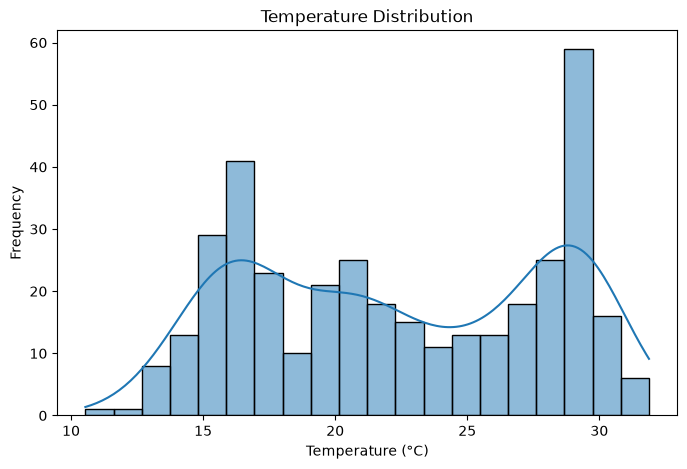

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df["temperature"], bins=20, kde=True)

plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")

plt.show()

## Precipitation Distribution

The histogram illustrates how daily precipitation values are distributed throughout the year.

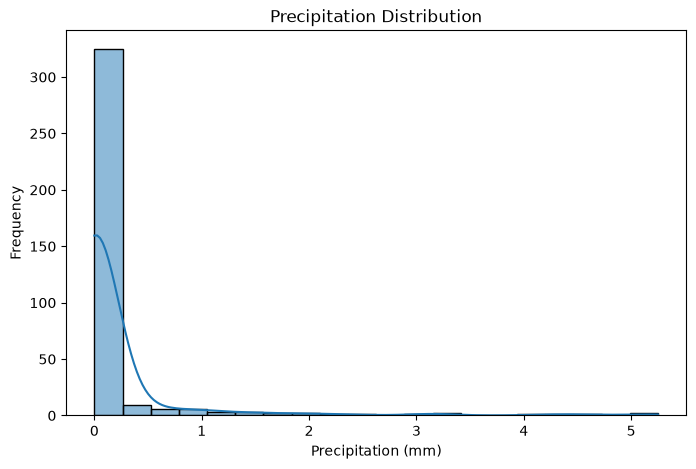

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(df["precipitation"], bins=20, kde=True)

plt.title("Precipitation Distribution")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")

plt.show()

## Temporal Patterns

This section investigates how temperature and precipitation change over time, highlighting trends, seasonal behaviour, and short-term variability.

### Daily Temperature

The following plot shows how the daily average temperature changes throughout the year.

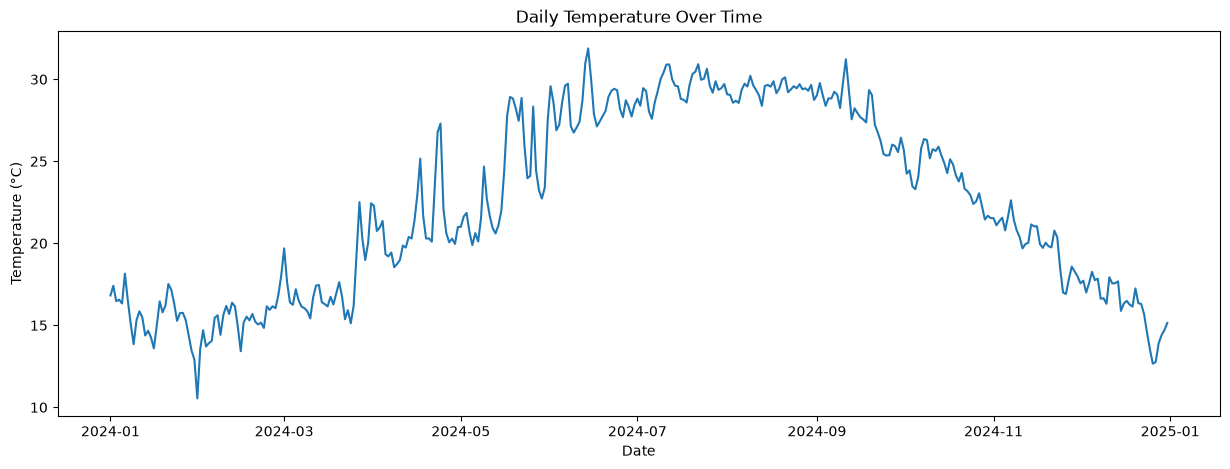

In [19]:
plt.figure(figsize=(15,5))

plt.plot(df.index, df["temperature"])

plt.title("Daily Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.show()

### Daily Precipitation

The following plot presents the daily precipitation values over the selected time period.

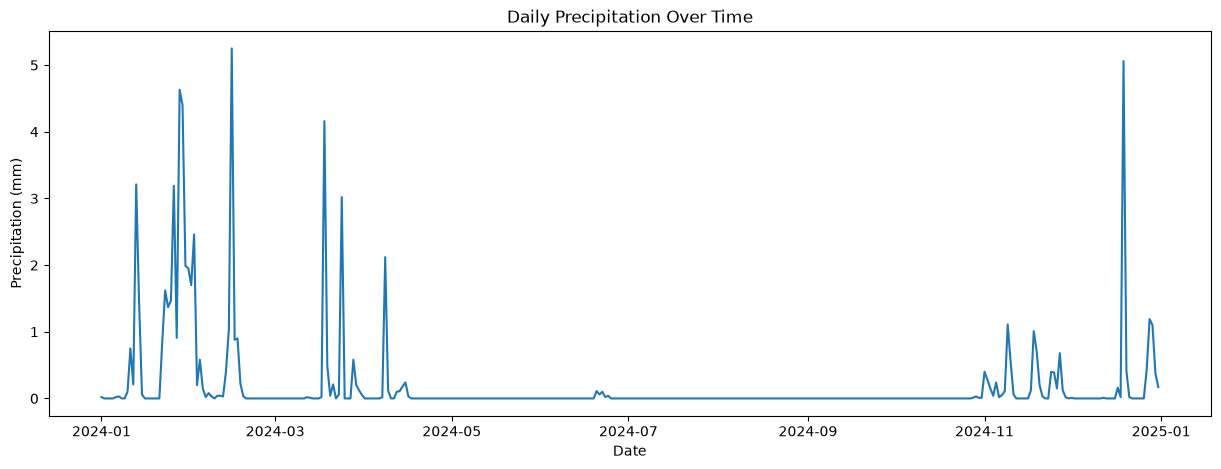

In [20]:
plt.figure(figsize=(15,5))

plt.plot(df.index, df["precipitation"])

plt.title("Daily Precipitation Over Time")
plt.xlabel("Date")
plt.ylabel("Precipitation (mm)")

plt.show()

### Trend Analysis

A 30-day rolling mean is calculated to smooth short-term fluctuations and highlight the overall temperature trend.

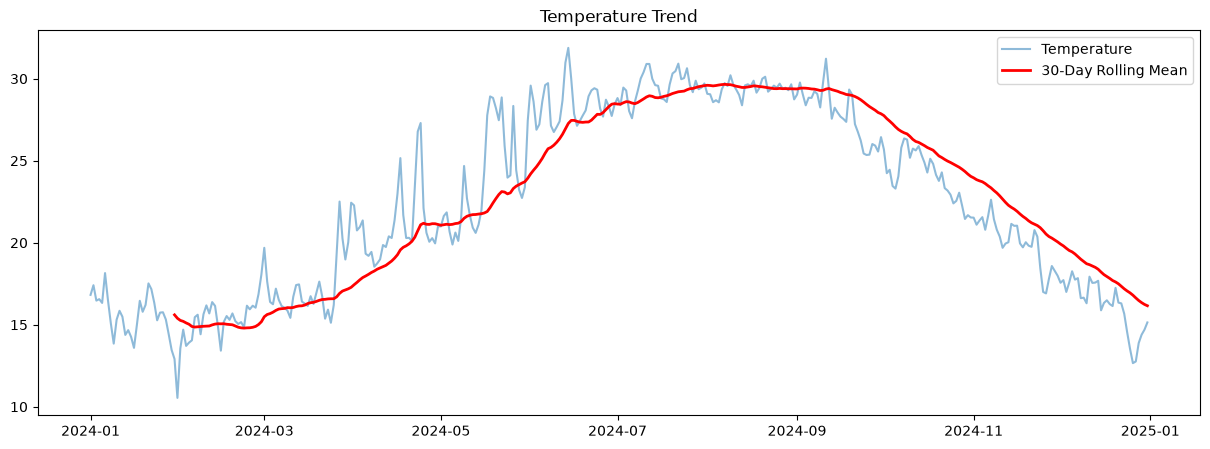

In [21]:
rolling_mean = df["temperature"].rolling(window=30).mean()

plt.figure(figsize=(15,5))

plt.plot(df.index, df["temperature"], alpha=0.5, label="Temperature")
plt.plot(df.index, rolling_mean, color="red", linewidth=2, label="30-Day Rolling Mean")

plt.title("Temperature Trend")

plt.legend()

plt.show()

### Rolling Statistics

The rolling standard deviation is used to measure how the variability of temperature changes over time.

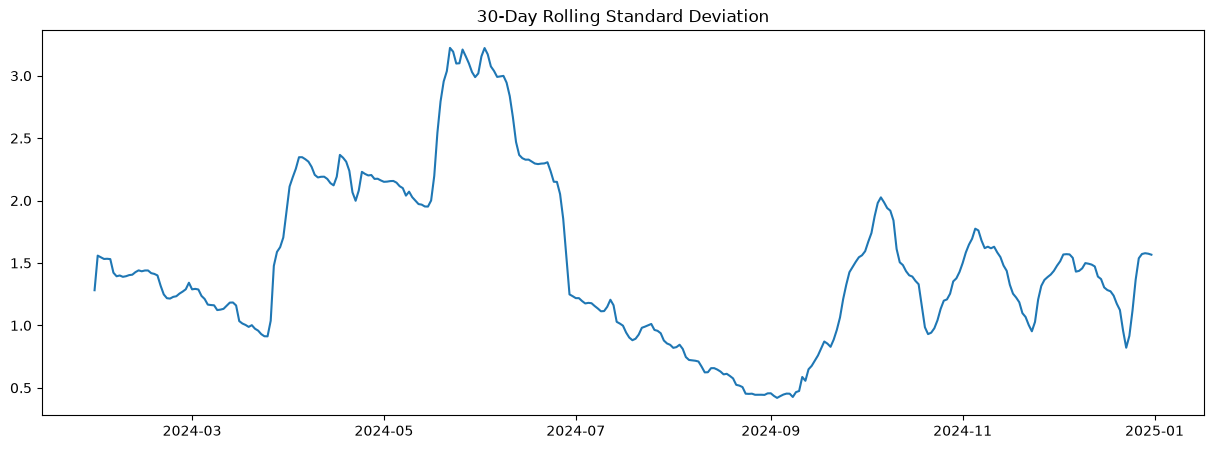

In [22]:
rolling_std = df["temperature"].rolling(window=30).std()

plt.figure(figsize=(15,5))

plt.plot(df.index, rolling_std)

plt.title("30-Day Rolling Standard Deviation")

plt.show()

### Seasonality Analysis

Monthly boxplots are used to compare the distribution of temperatures across different months and identify seasonal patterns.

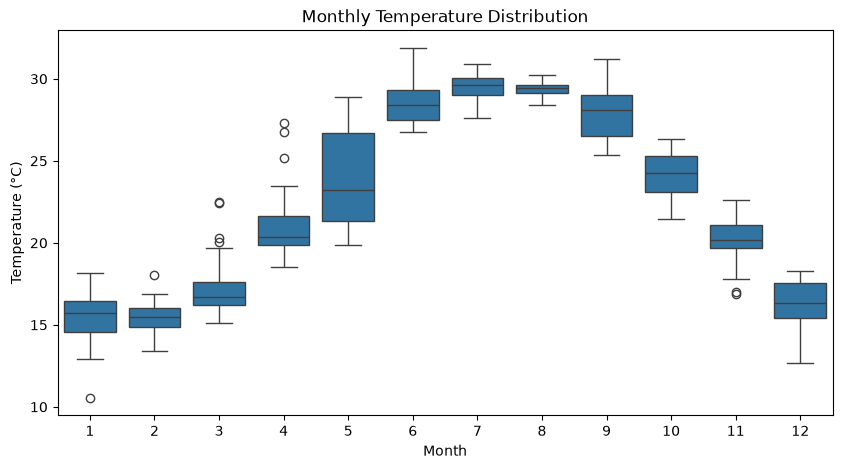

In [23]:
df["month"] = df.index.month

plt.figure(figsize=(10,5))

sns.boxplot(x="month",
            y="temperature",
            data=df)

plt.title("Monthly Temperature Distribution")

plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

plt.show()

## Decomposition and Structure

Seasonal decomposition separates the temperature time series into trend, seasonal, and residual components to better understand its underlying behaviour.

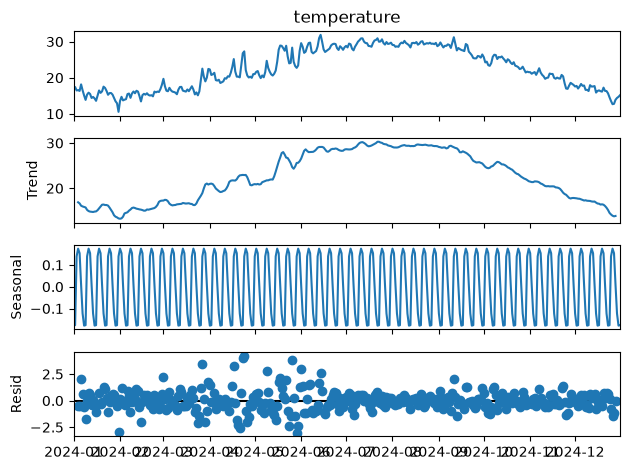

In [24]:
decomposition = seasonal_decompose(
    df["temperature"],
    model="additive",
    period=7
)

decomposition.plot()
plt.show()

### Autocorrelation (ACF)

The autocorrelation function (ACF) measures the correlation between observations at different time lags.

<Figure size 800x400 with 0 Axes>

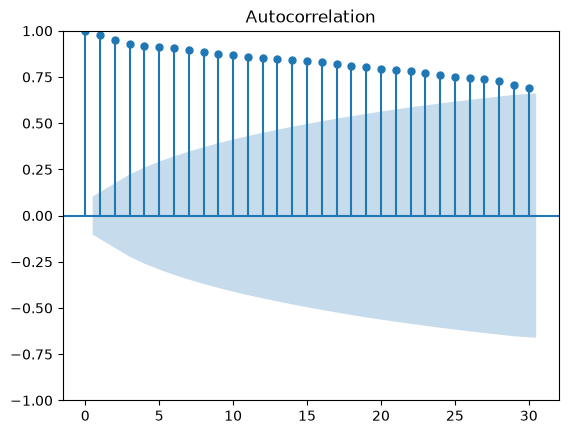

In [25]:
plt.figure(figsize=(8,4))

plot_acf(df["temperature"], lags=30)

plt.show()

### Partial Autocorrelation (PACF)

The partial autocorrelation function (PACF) measures the direct relationship between observations after removing the influence of intermediate lags.

<Figure size 800x400 with 0 Axes>

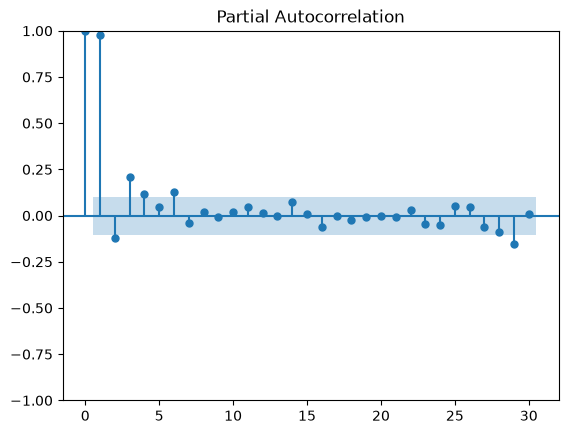

In [26]:
plt.figure(figsize=(8,4))

plot_pacf(df["temperature"], lags=30)

plt.show()

### Stationarity Test (ADF)

The Augmented Dickey-Fuller (ADF) test is performed to determine whether the temperature time series is stationary.

In [27]:
result = adfuller(df["temperature"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -0.7731118142706677
p-value: 0.8268929732656259
Critical Values:
1%: -3.448645946352023
5%: -2.869602139060357
10%: -2.5710650077160495


In [28]:
if result[1] < 0.05:
    print("The temperature series is stationary.")
else:
    print("The temperature series is non-stationary.")

The temperature series is non-stationary.


## Relationships and Anomalies

This section investigates the relationship between the collected weather variables and identifies potential anomalies in the dataset.

In [29]:
df[["temperature", "precipitation"]].corr()

,temperature,precipitation
temperature,1.000000,-0.346621
precipitation,-0.346621,1.000000


### Correlation Analysis

The correlation matrix and heatmap illustrate the strength and direction of the relationship between temperature and precipitation.

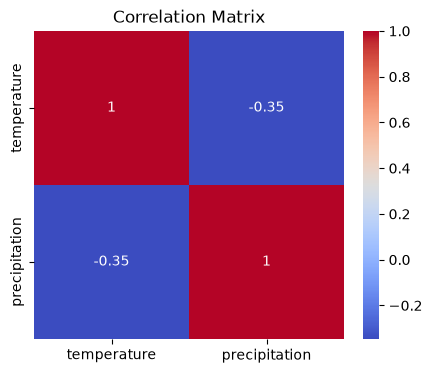

In [30]:
plt.figure(figsize=(5,4))

sns.heatmap(
    df[["temperature", "precipitation"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [31]:
df["z_score"] = zscore(df["temperature"])

outliers = df[np.abs(df["z_score"]) > 3]

outliers

,temperature,precipitation,month,z_score
date,,,,


### Outlier Detection

The Z-score method was used to detect unusually high or low temperature values.

No temperature outliers were identified using a threshold of |Z-score| > 3, indicating that the temperature values are within the expected range.

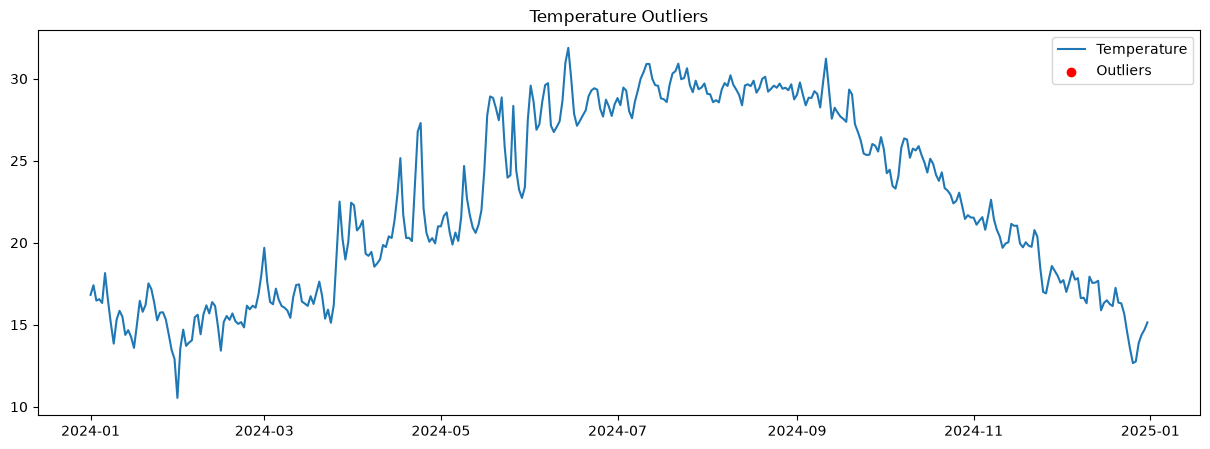

In [32]:
plt.figure(figsize=(15,5))

plt.plot(df.index, df["temperature"], label="Temperature")

plt.scatter(
    outliers.index,
    outliers["temperature"],
    color="red",
    label="Outliers"
)

plt.title("Temperature Outliers")

plt.legend()

plt.show()

In [33]:
suspicious = df[
    (df["temperature"] < -50) |
    (df["temperature"] > 60) |
    (df["precipitation"] < 0)
]

suspicious

,temperature,precipitation,month,z_score
date,,,,


### Suspicious Values

The dataset was checked for impossible weather observations such as:

- Temperature below -50°C
- Temperature above 60°C
- Negative precipitation

No suspicious values were found, suggesting that the data is consistent and contains no obvious measurement errors.

# Project Summary

This project analyzed historical weather data for **Alexandria, Egypt**, covering the period from **January 1, 2024, to December 31, 2024**. The data was obtained from the **NASA POWER API**, which was selected because it provides free and reliable historical meteorological data without requiring an API key. Daily observations of air temperature (T2M) and corrected precipitation (PRECTOTCORR) were retrieved and converted into a structured time-series dataset.

The exploratory data analysis revealed clear seasonal patterns in temperature. Temperatures were generally lower during the winter months and gradually increased towards the summer, reaching their highest values in July and August before decreasing again. The rolling mean confirmed this long-term seasonal trend, while the rolling standard deviation showed moderate variations throughout the year. Precipitation was relatively low for most of the year, with rainfall occurring mainly during the winter months, which is consistent with Alexandria's Mediterranean climate.

The Augmented Dickey-Fuller (ADF) test indicated that the temperature series is **non-stationary**, suggesting that its statistical properties change over time due to seasonal effects. This implies that transformations such as differencing or detrending may be required before applying forecasting models that assume stationarity.

Regarding data quality, no duplicated timestamps or missing values were found, and all variables were provided in consistent units (degrees Celsius for temperature and millimetres for precipitation). Outlier detection using the Z-score method did not identify any abnormal temperature values, and no suspicious observations, such as impossible temperatures or negative precipitation values, were detected. Therefore, no additional data cleaning or imputation was required before the exploratory analysis.